In [ ]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from pyDOE import lhs

a = 0.1
b = 1
c = 0.3
k = np.sqrt(a / (2 * (c**2 - a**2)))

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data

def random_fun(num):
    temp = torch.from_numpy(lb + (ub - lb) * lhs(2, num)).float()
    if use_gpu:
        temp = temp.cuda()
    return temp

class Net(nn.Module):
    def __init__(self, layers):
        super(Net, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a

def analytical_solution(t, x):
    u = torch.sqrt(torch.tensor(a/b)) * torch.tanh(k * (x - c * t))
    return u.reshape(-1, 1)

def analytical_solution_derivative(t, x):
    sech_term = 1.0 / torch.cosh(k * (x - c * t))
    u_t = -c * torch.sqrt(torch.tensor(a/b)) * k * (sech_term ** 2)
    return u_t.reshape(-1, 1)

def x_f_loss_fun(x, train_U):
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    
    u = train_U(x)
    
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)
    u_x = d[0][:, 1].unsqueeze(-1)
    
    u_tt = torch.autograd.grad(u_t, x, grad_outputs=torch.ones_like(u_t), create_graph=True)[0][:, [0]]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, [1]]
    
    f = u_tt - a**2 * u_xx + a * u - b * (u**3)
    
    return f

class Model:
    def __init__(self, net, x_bc, u_bc, x_ic, u_ic, u_ic_t, x_f_loss_fun, x_test, x_test_exact):
        self.net = net
        self.x_bc = x_bc
        self.u_bc = u_bc
        self.x_ic = x_ic
        self.u_ic = u_ic
        self.u_ic_t = u_ic_t
        self.x_f_loss_fun = x_f_loss_fun
        self.x_test = x_test
        self.x_test_exact = x_test_exact
        self.x_f_N = None
        self.x_f_M = None
        self.optimizer_LBGFS = None

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def epoch_loss(self):
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation = torch.mean(self.x_f_loss_fun(x_f, self.train_U) ** 2)
        
        loss_ic_u = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)
        
        x_ic_grad = Variable(self.x_ic, requires_grad=True)
        u0 = self.train_U(x_ic_grad)
        d = torch.autograd.grad(u0, x_ic_grad, grad_outputs=torch.ones_like(u0), create_graph=True)
        u0_t = d[0][:, 0].unsqueeze(-1)
        loss_ic_ut = torch.mean((u0_t - self.u_ic_t) ** 2)
        
        x_bc_grad = Variable(self.x_bc, requires_grad=True)
        u_bc_pred = self.train_U(x_bc_grad)
        d_bc = torch.autograd.grad(u_bc_pred, x_bc_grad, grad_outputs=torch.ones_like(u_bc_pred), create_graph=True)
        u_bc_x = d_bc[0][:, 1].unsqueeze(-1)
        loss_bc = torch.mean((u_bc_x - self.u_bc) ** 2)
        
        return loss_equation, loss_ic_u, loss_ic_ut, loss_bc

    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        
        loss_equation, loss_ic_u, loss_ic_ut, loss_bc = self.epoch_loss()
        total_loss = loss_equation + loss_ic_u + loss_ic_ut + loss_bc
        
        total_loss.backward()
        self.net.iter += 1
        
        return total_loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        exact = self.x_test_exact.cpu().detach().numpy()
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error

    def run_baseline(self):
        optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
        self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr, max_iter=lbgfs_iter)
        
        print("开始Adam训练...")
        pbar = trange(adam_iter, ncols=100)
        for i in pbar:
            optimizer_adam.zero_grad()
            loss_eq, loss_ic_u, loss_ic_ut, loss_bc = self.epoch_loss()
            
            total_loss = loss_eq + loss_ic_u + loss_ic_ut + loss_bc
            
            total_loss.backward()
            optimizer_adam.step()
            self.net.iter += 1
            
            if i % 500 == 0:
                pbar.set_description(f"Loss: {total_loss.item():.6e}")

        print('Adam训练完成!')
        
        print("开始LBFGS训练...")
        self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
        print('LBFGS训练完成!')

        error = self.evaluate()
        print('测试L2误差:', '{0:.2e}'.format(error))

    def train(self):
        self.x_f_N = random_fun(N)
        self.x_f_M = random_fun(M)

        start_time = time.time()
        self.run_baseline()
        elapsed = time.time() - start_time
        print('训练时间: %.2f秒' % elapsed)

def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    TT, XX = np.meshgrid(t, x)
    
    e = np.reshape(u_test_np, (TT.shape[0], TT.shape[1]))
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.pcolor(TT, XX, e, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('$x$', fontsize=16)
    plt.title(r'Analytical Solution $u(x,t)$', fontsize=16)

    e_pred = np.reshape(predict_np, (TT.shape[0], TT.shape[1]))
    plt.subplot(1, 2, 2)
    plt.pcolor(TT, XX, e_pred, cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('$x$', fontsize=16)
    plt.title(r'Pre $u(x,t)$', fontsize=16)
    
    plt.tight_layout()
    plt.show()

def draw_error():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test = x_test_exact.cpu().detach().numpy()
    XX1, XX2 = np.meshgrid(t, x)
    e = np.reshape(abs(predict_np - u_test), (XX1.shape[0], XX1.shape[1]))
    plt.pcolor(XX1, XX2, e, shading='auto', cmap='jet')
    plt.colorbar()
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('$x$', fontsize=16)
    plt.title('Absolute Error', fontsize=16)
    plt.tight_layout()
    plt.show()

GPU: True


In [ ]:
if __name__ == '__main__':
    lb = np.array([0.0, -10.0])
    ub = np.array([12.0, 10.0])

    layers = [2, 20, 20, 20, 20, 1]
    net = is_cuda(Net(layers))

    N = 500
    M = 500
    Nbc = 100
    Nic = 100

    adam_iter, lbgfs_iter = 3000, 500
    adam_lr, lbgfs_lr = 0.001, 0.5

    t = np.expand_dims(np.linspace(0, 12, 100), axis=1)
    x = np.expand_dims(np.linspace(-10, 10, 100), axis=1)
    X1, X2 = np.meshgrid(t, x)

    x_test_np = np.concatenate((np.vstack(np.expand_dims(X1, axis=2)), 
                               np.vstack(np.expand_dims(X2, axis=2))), axis=-1)
    
    t_test = torch.from_numpy(x_test_np[:, 0:1]).float()
    x_test_coords = torch.from_numpy(x_test_np[:, 1:2]).float()
    solution = analytical_solution(t_test, x_test_coords).numpy()
    
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    x_test_exact = is_cuda(torch.from_numpy(solution).float())

    x_init = torch.from_numpy(x).float()
    t_init = torch.zeros(Nic, 1)
    x_initial = torch.cat((t_init, x_init), dim=1)
    
    u_initial = analytical_solution(t_init, x_init)
    u_initial_t = analytical_solution_derivative(t_init, x_init)
    
    t_bc = torch.rand([Nbc, 1]) * 12.0
    x_boundary_left = torch.cat((t_bc[:Nbc//2], torch.full([Nbc//2, 1], -10.0)), dim=1)
    x_boundary_right = torch.cat((t_bc[Nbc//2:], torch.full([Nbc//2, 1], 10.0)), dim=1)
    
    t_left = x_boundary_left[:, 0:1]
    x_left = x_boundary_left[:, 1:2]
    t_right = x_boundary_right[:, 0:1]
    x_right = x_boundary_right[:, 1:2]
    
    sech_left = 1.0 / torch.cosh(k * (-10.0 - c * t_left))
    u_x_left_target = k * torch.sqrt(torch.tensor(a/b)) * (sech_left ** 2)
    
    sech_right = 1.0 / torch.cosh(k * (10.0 - c * t_right))
    u_x_right_target = k * torch.sqrt(torch.tensor(a/b)) * (sech_right ** 2)

    x_ic = is_cuda(x_initial)
    u_ic = is_cuda(u_initial)
    u_ic_t = is_cuda(u_initial_t)
    x_bc = is_cuda(torch.cat((x_boundary_left, x_boundary_right), dim=0))
    u_bc = is_cuda(torch.cat((u_x_left_target, u_x_right_target), dim=0))

    model = Model(
        net=net,
        x_bc=x_bc,
        u_bc=u_bc,
        x_ic=x_ic, 
        u_ic=u_ic,
        u_ic_t=u_ic_t,
        x_f_loss_fun=x_f_loss_fun,
        x_test=x_test,
        x_test_exact=x_test_exact,
    )
    
    print("开始训练无源项Klein-Gordon方程...")
    model.train()

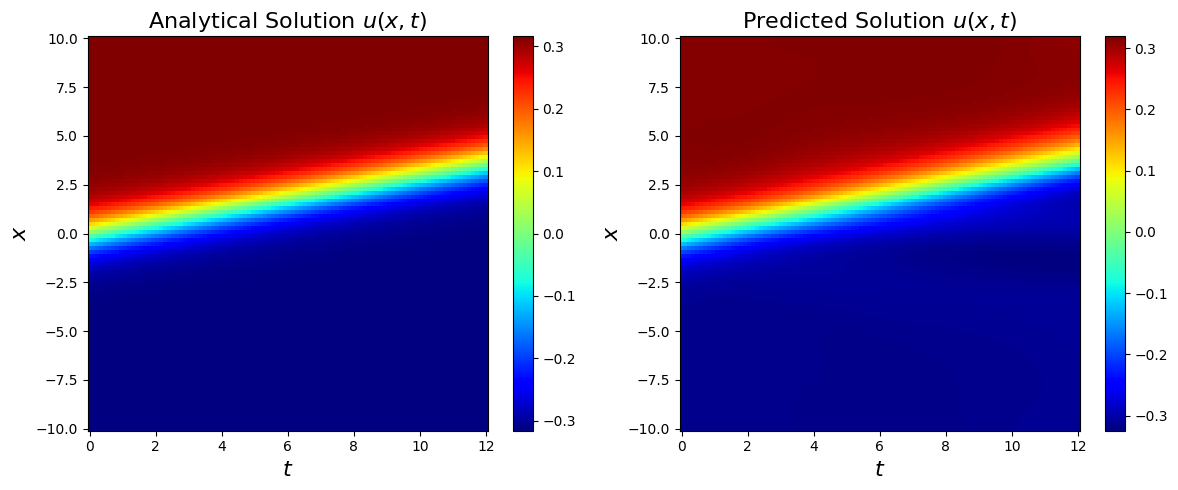

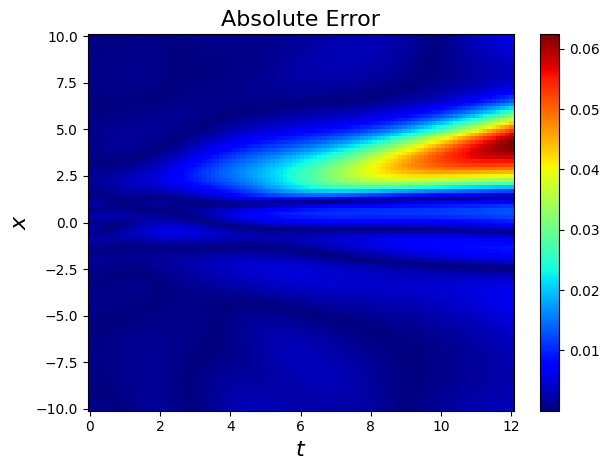

In [ ]:
draw_exact()
draw_error()